In [1]:
# pip install --upgrade google-cloud-bigquery
# pip install pydata-google-auth
# pip install db-dtypes

In [2]:
# Turn off warnings
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Authenticate through your browser with you Big Query account
import pydata_google_auth

scopes = ['https://www.googleapis.com/auth/bigquery']

credentials = pydata_google_auth.get_user_credentials(
    scopes,
    # Set auth_local_webserver to True for a more convenient flow,
    # but be aware it may not work on a remote server
    # like a cloud-hosted notebook if there are network restrictions
    # auth_local_webserver=True, # Optional
)

In [4]:
from google.cloud import bigquery

project = 'product-project-463105'

client = bigquery.Client(project=project,credentials=credentials)
google_citibike = '`bigquery-public-data.new_york_citibike.citibike_trips`'

# Question 2, Part A

In [5]:
# Analysis parameters cell
# Adding paremeters to be inserted with f-strings is a convenient way of working with BQ client in notebooks
# Helps make the work a bit easier to reuse, etc

year = '2015'
morning_rush = "'07:00:00' AND '10:00:00'"
evening_rush = "'16:00:00' AND '19:00:00'"

In [6]:

# What was the busiest start station by trip count, and how many trips started there?
query = f'''
-- Count distinct trips and use qualify with rank to get the start_station_id with the most trips
SELECT start_station_id, start_station_name, COUNT(DISTINCT bikeid || CAST(starttime AS STRING)) d_trips
FROM
`bigquery-public-data.new_york_citibike.citibike_trips`

WHERE EXTRACT(YEAR FROM starttime) = {year}
GROUP BY 1,2
--ORDER BY 3 DESC

QUALIFY RANK() OVER(ORDER BY COUNT(*) DESC) = 1;

'''
# print(query) # uncomment to see query with parmeter vals included
busy_station_df = client.query(query).to_dataframe()
busy_station_df

,start_station_id,start_station_name,d_trips
0,519,Pershing Square North,104813


### Q: What was the busiest start station by trip count, and how many trips started there?
### A: The busiest station is Pershing Square North, adjacent to Grand Central. This makes sense as a commuter hub.<br>

In [7]:

# What was the median trip duration for Subscriber vs Customer? How do you read the gap?
query = f'''
-- median trip length by usertype
SELECT DISTINCT usertype, PERCENTILE_CONT(tripduration, 0.5) OVER(PARTITION BY usertype) AS median_tripduration
FROM
`bigquery-public-data.new_york_citibike.citibike_trips`

WHERE EXTRACT(YEAR FROM starttime) = {year}
AND usertype IS NOT NULL;

'''
# print(query) # uncomment to see query with parmeter vals included
median_duration_df = client.query(query).to_dataframe()
# Convert seconds to minutes
median_duration_df['median_minutes'] = (median_duration_df['median_tripduration'] / 60).round(1)
median_duration_df[['usertype','median_minutes']]

,usertype,median_minutes
0,Customer,20.5
1,Subscriber,9.6


### Q: What was the median trip duration for Subscriber vs Customer? How do you read the gap?
### A: Customers ride at a median of ~20.5 minutes vs ~9.6 for Subscribers. The gap reflects different use cases.
### Subscribers are commuters doing short point-to-point trips, Customers are casual/tourist riders on longer leisure trips.<br>

In [8]:

# What share of trips were round trips (same start and end station)? 
query = f'''
-- Get the pct of roundtrip trips using distinct inside the count to make robust to dups
SELECT ROUND(COUNT(DISTINCT CASE WHEN start_station_id = end_station_id THEN bikeid || CAST(starttime AS STRING) END) / 
        COUNT(DISTINCT bikeid || CAST(starttime AS STRING)) * 100.0,1) pct_roundtrip
FROM
`bigquery-public-data.new_york_citibike.citibike_trips` 

WHERE EXTRACT(YEAR FROM starttime) = {year};

'''

pct_rndtrip_df = client.query(query).to_dataframe()
display(pct_rndtrip_df.style.format({'pct_roundtrip': '{:.0f}%'}))


# Does it differ by user type?
query = f'''
-- Adding usertype cut to the above query
SELECT usertype, ROUND(COUNT(DISTINCT CASE WHEN start_station_id = end_station_id THEN bikeid || CAST(starttime AS STRING) END) / 
        COUNT(DISTINCT bikeid || CAST(starttime AS STRING)) * 100.0,1) pct_roundtrip
FROM
`bigquery-public-data.new_york_citibike.citibike_trips`

WHERE EXTRACT(YEAR FROM starttime) = {year}
GROUP BY 1;

'''
# print(query) # uncomment to see query with parmeter vals included
pct_rndtrip_type_df = client.query(query).to_dataframe()
pct_rndtrip_type_df.style.format({'pct_roundtrip': '{:.2f}%'})

,pct_roundtrip
0,2%


,usertype,pct_roundtrip
0,Subscriber,1.50%
1,Customer,7.20%


### Q: What share of trips were round trips (same start and end station)? Does it differ by user type?
### A: 2% overall, 5.9% for Customers vs 1.5% for Subscribers. Citibike is designed for one-way trips. 
### Round trips are almost entirely a leisure behavior, which is why Customers are 4x more likely to do them.

In [9]:
# Among the top 20 start stations by volume, which station has the most lopsided rush-hour split (share of trips starting 7–10am vs 4–7pm on weekdays)? 
# Define “lopsided” however you want, but say what you mean. What might that tell you?
query = f'''
-- q4
WITH t20 AS
(
SELECT start_station_id
FROM
`bigquery-public-data.new_york_citibike.citibike_trips`

WHERE EXTRACT(YEAR FROM starttime) = {year}
GROUP BY 1
QUALIFY RANK() OVER( ORDER BY COUNT(DISTINCT bikeid || CAST(starttime AS STRING)) DESC) <=20
),
am_pm AS
(
SELECT t.start_station_id, t.start_station_name,
  COUNT(DISTINCT
        CASE WHEN CAST(starttime AS TIME) BETWEEN {morning_rush} THEN bikeid || CAST(starttime AS STRING) END
        ) / COUNT(DISTINCT bikeid || CAST(starttime AS STRING)) am_rush_hr,
  COUNT(DISTINCT
        CASE WHEN CAST(starttime AS TIME) BETWEEN {evening_rush} THEN bikeid || CAST(starttime AS STRING) END
        ) / COUNT(DISTINCT bikeid || CAST(starttime AS STRING)) pm_rush_hr
FROM
`bigquery-public-data.new_york_citibike.citibike_trips` t
JOIN 
t20
ON t.start_station_id = t20.start_station_id
WHERE EXTRACT(YEAR FROM starttime) = {year}
AND EXTRACT(DAYOFWEEK FROM starttime) BETWEEN 2 AND 6
GROUP BY 1,2
)
SELECT start_station_id, start_station_name, am_rush_hr, pm_rush_hr, ABS(am_rush_hr - pm_rush_hr) abs_diff

FROM am_pm
QUALIFY RANK() OVER(ORDER BY ABS(am_rush_hr - pm_rush_hr) DESC) <= 2
ORDER BY 5 DESC

'''
# print(query) # uncomment to see query with parmeter vals included
am_pm_df = client.query(query).to_dataframe()
am_pm_df.columns = ['start_station_id',	'start_station_name', 'am_rush_hr',	'pm_rush_hr', 'pctg_point_diff']
am_pm_df.style.format({'am_rush_hr': '{:.1%}', 'pm_rush_hr': '{:.1%}','pctg_point_diff': lambda x: f"{x * 100:.1f}"})

,start_station_id,start_station_name,am_rush_hr,pm_rush_hr,pctg_point_diff
0,521,8 Ave & W 31 St,49.9%,10.4%,39.5
1,529,W 42 St & 8 Ave,46.4%,8.2%,38.1


### Q: Among the top 20 start stations by volume, which station has the most lopsided rush-hour split (share of trips starting 7–10am vs 4–7pm on weekdays)?
### Define “lopsided” however you want, but say what you mean. What might that tell you?
### A: 8 Ave & W 31 St is the most lopsided and is overwhelmingly AM-heavy (50% AM vs 10.4% PM). To find lopsidedness, I'm using absolute difference between AM and PM rush hours. This way I can easily sort by the magnitude of the difference. 

### The location is right next to Penn Station, suggesting commuters are coming into Penn Station and biking to work from there. The next most lopsided station, W 42 St & 8 Ave, is also AM heavy and by a major commuter hub Port Authority Bus Terminal.
### This is a different pattern than previously found in 2017 when more of the citibike users seemed to be using the bikes for leisure after work.

# Question 2, Part B
## Option 1 - The two user types tell different stories. 

# PART B uses a 10% random sample deterministic sample of the 2015 dataset (approximately 997K trips) for efficient exploration. 
# Part A answers were computed on the full dataset. All patterns and proportions hold at full scale.

In [10]:
%%time

# Pulling in a random, deterministic sample to do EDA with - 10% sample
# This can run quickly on BQ but takes some time to load into the df. This 10% sample took about 3 minutes and 30 seconds
query = f'''
SELECT *
FROM `bigquery-public-data.new_york_citibike.citibike_trips`
WHERE EXTRACT(YEAR FROM starttime) = {year}
AND MOD(ABS(FARM_FINGERPRINT(bikeid || CAST(starttime AS STRING))), 100) < 10 -- grabs a repeatable sample
'''
# print(query) # uncomment to see query with parmeter vals included
citibikes_df = client.query(query).to_dataframe()
citibikes_df

CPU times: total: 1min 12s
Wall time: 3min 31s


,tripduration,starttime,stoptime,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,customer_plan
0,1455,2015-10-15 10:40:31,2015-10-15 11:04:47,3122,48 Ave & 5 St,40.744363,-73.955873,3141,1 Ave & E 68 St,40.765005,-73.958185,23458,Subscriber,1962,male,
1,633,2015-11-08 15:52:45,2015-11-08 16:03:19,3122,48 Ave & 5 St,40.744363,-73.955873,3117,Franklin St & Dupont St,40.735640,-73.958660,23435,Subscriber,1996,male,
2,1298,2015-12-11 08:57:42,2015-12-11 09:19:20,3229,Marcy Ave & MacDonough St,40.680618,-73.946249,418,Front St & Gold St,40.702240,-73.982578,18009,Subscriber,1971,male,
3,568,2015-12-16 13:26:32,2015-12-16 13:36:01,3234,E 40 St & Madison Ave,40.751594,-73.980432,3233,E 48 St & 5 Ave,40.757246,-73.978059,20815,Subscriber,1951,male,
4,2362,2015-11-06 09:23:47,2015-11-06 10:03:10,3234,E 40 St & Madison Ave,40.751594,-73.980432,195,Liberty St & Broadway,40.709056,-74.010434,14761,Subscriber,1960,male,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996587,1697,2015-05-31 13:15:57,2015-05-31 13:44:15,363,West Thames St,40.708347,-74.017134,358,Christopher St & Greenwich St,40.732916,-74.007114,16424,Customer,<NA>,unknown,
996588,1248,2015-08-02 19:04:48,2015-08-02 19:25:36,3002,South End Ave & Liberty St,40.711512,-74.015756,358,Christopher St & Greenwich St,40.732916,-74.007114,22532,Customer,<NA>,unknown,
996589,1073,2015-08-02 11:43:07,2015-08-02 12:01:01,514,12 Ave & W 40 St,40.760875,-74.002777,358,Christopher St & Greenwich St,40.732916,-74.007114,19003,Customer,<NA>,unknown,
996590,11301,2015-10-23 15:31:15,2015-10-23 18:39:37,151,Cleveland Pl & Spring St,40.722104,-73.997249,358,Christopher St & Greenwich St,40.732916,-74.007114,17868,Customer,<NA>,unknown,


In [11]:
# look at the column names
citibikes_df.columns

Index(['tripduration', 'starttime', 'stoptime', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bikeid', 'usertype',
       'birth_year', 'gender', 'customer_plan'],
      dtype='object')

In [12]:
# Convert the numerical IDs to string
num_ids = ['start_station_id','end_station_id', 'bikeid']

citibikes_df[num_ids] = citibikes_df[num_ids].astype("string")
citibikes_df.head()

,tripduration,starttime,stoptime,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,customer_plan
0,1455,2015-10-15 10:40:31,2015-10-15 11:04:47,3122,48 Ave & 5 St,40.744363,-73.955873,3141,1 Ave & E 68 St,40.765005,-73.958185,23458,Subscriber,1962,male,
1,633,2015-11-08 15:52:45,2015-11-08 16:03:19,3122,48 Ave & 5 St,40.744363,-73.955873,3117,Franklin St & Dupont St,40.735640,-73.958660,23435,Subscriber,1996,male,
2,1298,2015-12-11 08:57:42,2015-12-11 09:19:20,3229,Marcy Ave & MacDonough St,40.680618,-73.946249,418,Front St & Gold St,40.702240,-73.982578,18009,Subscriber,1971,male,
3,568,2015-12-16 13:26:32,2015-12-16 13:36:01,3234,E 40 St & Madison Ave,40.751594,-73.980432,3233,E 48 St & 5 Ave,40.757246,-73.978059,20815,Subscriber,1951,male,
4,2362,2015-11-06 09:23:47,2015-11-06 10:03:10,3234,E 40 St & Madison Ave,40.751594,-73.980432,195,Liberty St & Broadway,40.709056,-74.010434,14761,Subscriber,1960,male,


In [13]:
# look at the numerical cols
citibikes_df.describe()

,tripduration,starttime,stoptime,start_station_latitude,start_station_longitude,end_station_latitude,end_station_longitude,birth_year
count,996592.0,996592,996592,996592.000000,996592.000000,996592.000000,996592.000000,865233.0
mean,972.107766,2015-08-05 19:28:23.576001,2015-08-05 19:44:36.070179,40.735941,-73.989455,40.735649,-73.989610,1976.559745
min,60.0,2015-01-01 00:01:00,2015-01-01 00:24:00,40.646768,-74.017134,40.646768,-74.038051,1885.0
25%,389.0,2015-06-03 13:30:00,2015-06-03 13:45:00,40.721816,-73.999318,40.721655,-73.999733,1969.0
50%,629.0,2015-08-14 07:10:09.500000,2015-08-14 07:24:22,40.737050,-73.990214,40.736529,-73.990541,1979.0
75%,1048.0,2015-10-14 14:27:41.250000,2015-10-14 14:46:17.250000,40.750977,-73.981346,40.750967,-73.981420,1986.0
max,2937702.0,2015-12-31 23:57:20,2016-01-12 08:08:25,40.787209,-73.929891,40.787209,-73.929891,1999.0
std,7257.712208,NaN,NaN,0.020439,0.013986,0.020379,0.013997,11.558766


In [14]:
# look at the cat columns

num_cols = citibikes_df.describe().columns


# [col for col in citibikes_df.columns if col not in num_cols]
cat_df = citibikes_df.loc[:, ~citibikes_df.columns.isin(num_cols)]


cat_df.describe()

,start_station_id,start_station_name,end_station_id,end_station_name,bikeid,usertype,gender,customer_plan
count,996592,996592,996592,996592,996592,996592,996592,996592
unique,488,496,492,500,8435,2,3,1
top,519,Pershing Square North,519,Pershing Square North,22123,Subscriber,male,
freq,10342,10342,9735,9735,209,865239,662453,996592


In [15]:
# Check for nulls
citibikes_df.isnull().sum()

tripduration                    0
starttime                       0
stoptime                        0
start_station_id                0
start_station_name              0
start_station_latitude          0
start_station_longitude         0
end_station_id                  0
end_station_name                0
end_station_latitude            0
end_station_longitude           0
bikeid                          0
usertype                        0
birth_year                 131359
gender                          0
customer_plan                   0
dtype: int64

In [16]:
# Check for empty strings
cat_df.apply(lambda col: col.str.strip().eq('').sum())

start_station_id           0
start_station_name         0
end_station_id             0
end_station_name           0
bikeid                     0
usertype                   0
gender                     0
customer_plan         996592
dtype: int64

In [17]:
# Create a trip id
citibikes_df['trip_id'] = citibikes_df['bikeid'] + "_" + citibikes_df['starttime'].astype(str)
citibikes_df['trip_id'] 

0         23458_2015-10-15 10:40:31
1         23435_2015-11-08 15:52:45
2         18009_2015-12-11 08:57:42
3         20815_2015-12-16 13:26:32
4         14761_2015-11-06 09:23:47
                    ...            
996587    16424_2015-05-31 13:15:57
996588    22532_2015-08-02 19:04:48
996589    19003_2015-08-02 11:43:07
996590    17868_2015-10-23 15:31:15
996591    21338_2015-04-16 12:21:02
Name: trip_id, Length: 996592, dtype: string

In [18]:
# Check for dups
citibikes_df['trip_id'].duplicated().sum()

0

In [19]:
# Add some helper columns
citibikes_df['strt_hr'] = citibikes_df['starttime'].dt.hour
citibikes_df['end_hr'] = citibikes_df['stoptime'].dt.hour
citibikes_df['month'] = citibikes_df['starttime'].dt.month
citibikes_df['month_name'] = citibikes_df['starttime'].dt.month_name()
citibikes_df['weekday'] = (citibikes_df['starttime'].dt.weekday + 1) % 7 # setting Sunday as start of week

<Axes: title={'center': 'Trips by Hour'}, xlabel='strt_hr'>

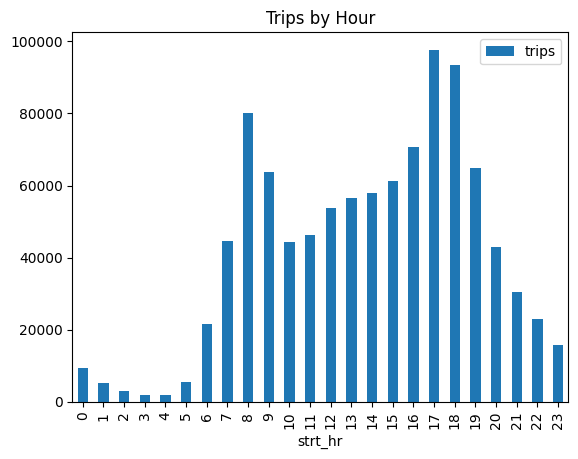

In [20]:
# Check rides by hour
hourly_trips = citibikes_df.groupby(by=['strt_hr'])['trip_id'].count().reset_index()
hourly_trips.columns = ['strt_hr','trips']
# hourly_trips['month_name'] = pd.to_datetime(hourly_trips['month'], format='%m').dt.month_name()
hourly_trips.sort_values(by='strt_hr')
hourly_trips.plot(x='strt_hr', y='trips', kind='bar', title='Trips by Hour')

<Axes: title={'center': 'Trips by Weekday'}, xlabel='day_name'>

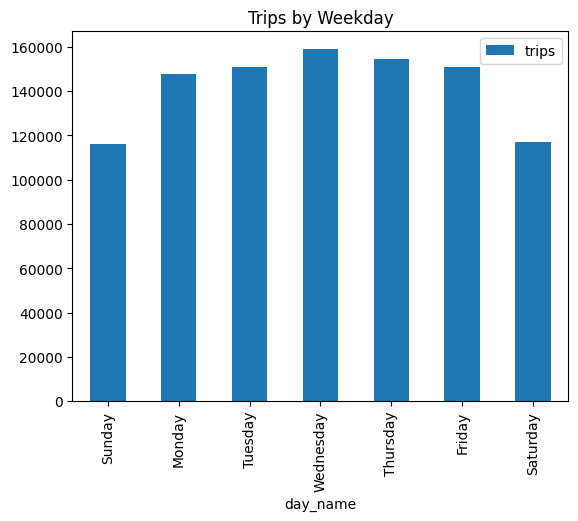

In [21]:
# Check rides by day

# need a day name map since I changed the start of the week to Sunday
day_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 
           4: 'Thursday', 5: 'Friday', 6: 'Saturday'}

daily_trips = citibikes_df.groupby(by=['weekday'])['trip_id'].count().reset_index()
daily_trips.columns = ['weekday','trips']
daily_trips['day_name'] = daily_trips['weekday'].map(day_map)
daily_trips.sort_values(by='weekday')
daily_trips.plot(x='day_name', y='trips', kind='bar', title='Trips by Weekday')

<Axes: title={'center': 'Trips by Month'}, xlabel='month_name'>

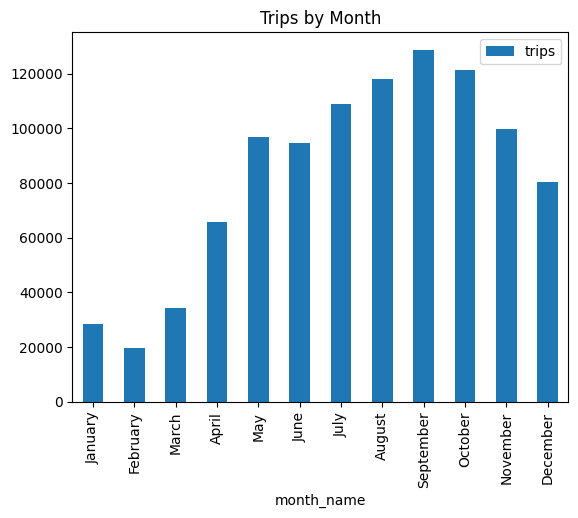

In [22]:
# Check rides by month
monthly_trips = citibikes_df.groupby(by=['month'])['trip_id'].count().reset_index()
monthly_trips.columns = ['month','trips']
monthly_trips['month_name'] = pd.to_datetime(monthly_trips['month'], format='%m').dt.month_name()
monthly_trips.sort_values(by='month')
monthly_trips.plot(x='month_name', y='trips', kind='bar', title='Trips by Month')

In [23]:
# Check the pct split by usertype
trips_by_type = citibikes_df.groupby(by='usertype')['trip_id'].count().reset_index()
trips_by_type.columns = ['usertype','trips']
trips_by_type['pct'] = round((trips_by_type['trips'] / sum(trips_by_type['trips'])) * 100,1)
trips_by_type

,usertype,trips,pct
0,Customer,131353,13.2
1,Subscriber,865239,86.8


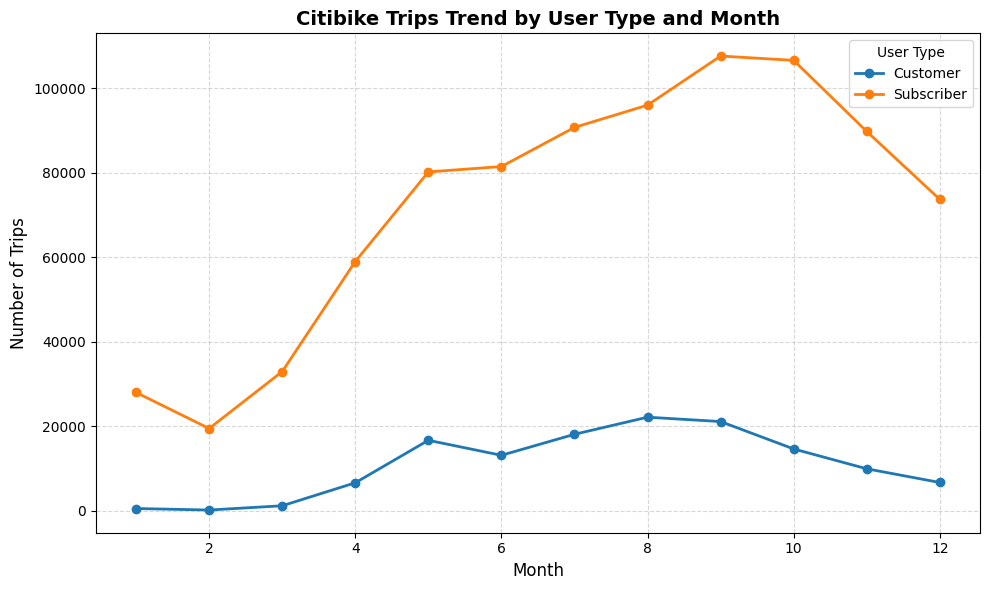

In [24]:


# pivot df
chart_df = citibikes_df.groupby(by=['month','usertype'])['trip_id'].count().reset_index()
pivot_df = chart_df.pivot(index='month', columns='usertype', values='trip_id')

# plot trend lines
# marker='o' adds distinct points on the lines for each month
ax = pivot_df.plot.line(figsize=(10, 6), marker='o', linewidth=2)

plt.title('Citibike Trips Trend by User Type and Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)  # Enables both X and Y grid lines for trend tracking
plt.legend(title='User Type')

plt.tight_layout()
plt.show()

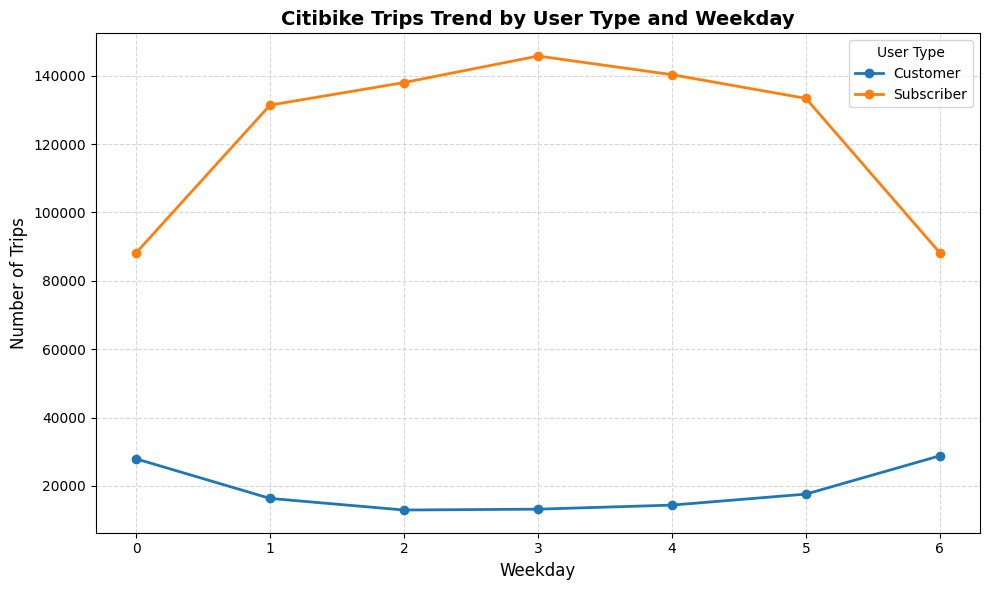

In [25]:
# Usertype and Weekday

# pivot df
chart_df = citibikes_df.groupby(by=['weekday','usertype'])['trip_id'].count().reset_index()
pivot_df = chart_df.pivot(index='weekday', columns='usertype', values='trip_id')

# plot trend lines
# marker='o' adds distinct points on the lines for each month
ax = pivot_df.plot.line(figsize=(10, 6), marker='o', linewidth=2)

plt.title('Citibike Trips Trend by User Type and Weekday', fontsize=14, fontweight='bold')
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)  # Enables both X and Y grid lines for trend tracking
plt.legend(title='User Type')

plt.tight_layout()
plt.show()

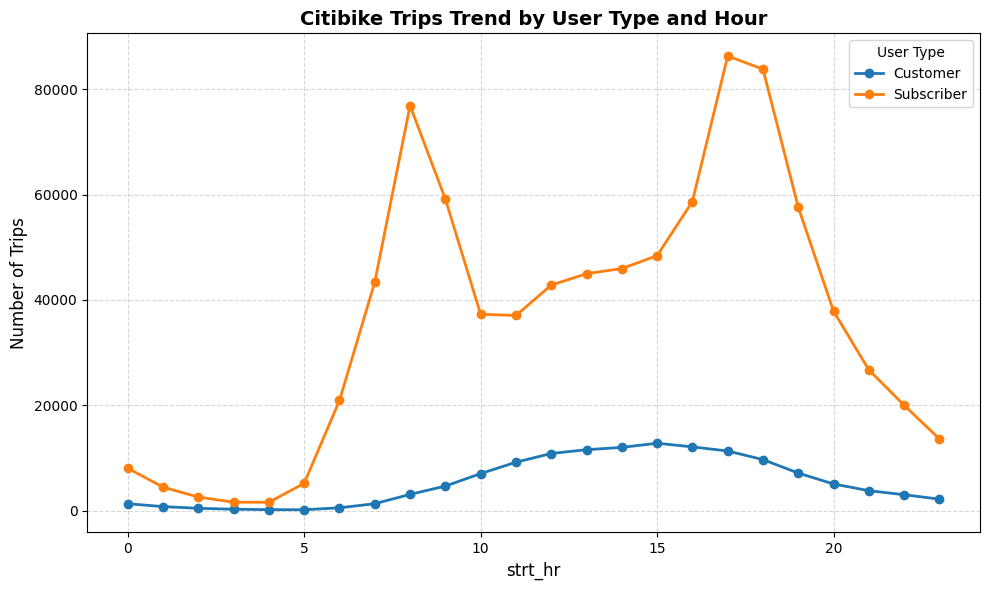

In [26]:

# pivot df
chart_df = citibikes_df.groupby(by=['strt_hr','usertype'])['trip_id'].count().reset_index()
pivot_df = chart_df.pivot(index='strt_hr', columns='usertype', values='trip_id')

# plot trend lines
# marker='o' adds distinct points on the lines for each month
ax = pivot_df.plot.line(figsize=(10, 6), marker='o', linewidth=2)

plt.title('Citibike Trips Trend by User Type and Hour', fontsize=14, fontweight='bold')
plt.xlabel('strt_hr', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)  # Enables both X and Y grid lines for trend tracking
plt.legend(title='User Type')

plt.tight_layout()
plt.show()

In [27]:
### Adding routes to the DF 

citibikes_df['route'] = citibikes_df.apply(
    lambda x: x['start_station_name'] + ' → ' + x['end_station_name'] 
    if x['start_station_name'] != x['end_station_name'] 
    else x['start_station_name'] + ' (round trip)', axis=1)

In [28]:
citibikes_df.columns

Index(['tripduration', 'starttime', 'stoptime', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bikeid', 'usertype',
       'birth_year', 'gender', 'customer_plan', 'trip_id', 'strt_hr', 'end_hr',
       'month', 'month_name', 'weekday', 'route'],
      dtype='object')

In [29]:
# View top 10 stations overall with usertype cuts

chart_df = citibikes_df.groupby(by=['start_station_name','usertype'])['trip_id'].count().reset_index()
chart_df.columns = ['start_station_name','usertype','trips']
chart_df['total_trips'] = chart_df.groupby('start_station_name')['trips'].transform('sum')
chart_df = chart_df.sort_values('total_trips', ascending=False).head(20).reset_index(drop=True)



chart_df

,start_station_name,usertype,trips,total_trips
0,Pershing Square North,Customer,771,10342
1,Pershing Square North,Subscriber,9571,10342
2,8 Ave & W 31 St,Customer,734,10225
3,8 Ave & W 31 St,Subscriber,9491,10225
4,Lafayette St & E 8 St,Customer,757,9736
5,Lafayette St & E 8 St,Subscriber,8979,9736
6,W 21 St & 6 Ave,Customer,462,8796
7,W 21 St & 6 Ave,Subscriber,8334,8796
8,E 17 St & Broadway,Subscriber,7637,8582
9,E 17 St & Broadway,Customer,945,8582


In [30]:
# Get top 10 subscriber start and stop stations
subscriber_df = citibikes_df[citibikes_df['usertype'] == 'Subscriber']

subs_top_start = subscriber_df.groupby(by=['start_station_name','start_station_latitude','start_station_longitude'])['trip_id'].count().reset_index()
subs_top_start = subs_top_start.sort_values('trip_id', ascending=False).head(10).reset_index(drop=True)
subs_top_start.columns = ['top_start_station_subscriber','start_lat', 'start_long', 'trips']
display(subs_top_start)


subs_top_end = subscriber_df.groupby(by=['end_station_name','end_station_latitude','end_station_longitude'])['trip_id'].count().reset_index()
subs_top_end = subs_top_end.sort_values('trip_id', ascending=False).head(10).reset_index(drop=True)
subs_top_end.columns = ['top_end_station_subscriber','end_lat','end_long','trips']
subs_top_end

,top_start_station_subscriber,start_lat,start_long,trips
0,Pershing Square North,40.751873,-73.977706,9571
1,Lafayette St & E 8 St,40.730287,-73.990765,8979
2,W 21 St & 6 Ave,40.741740,-73.994156,8334
3,E 17 St & Broadway,40.737050,-73.990093,7637
4,8 Ave & W 31 St,40.750967,-73.994442,7558
5,Broadway & E 14 St,40.734546,-73.990741,6693
6,Broadway & E 22 St,40.740343,-73.989551,6225
7,8 Ave & W 33 St,40.751551,-73.993934,6199
8,W 41 St & 8 Ave,40.756405,-73.990026,6156
9,West St & Chambers St,40.717548,-74.013221,5924


,top_end_station_subscriber,end_lat,end_long,trips
0,Pershing Square North,40.751873,-73.977706,9000
1,Lafayette St & E 8 St,40.730287,-73.990765,8952
2,W 21 St & 6 Ave,40.741740,-73.994156,8437
3,E 17 St & Broadway,40.737050,-73.990093,8035
4,Broadway & E 14 St,40.734546,-73.990741,6789
5,W 41 St & 8 Ave,40.756405,-73.990026,6587
6,Broadway & E 22 St,40.740343,-73.989551,6179
7,8 Ave & W 31 St,40.750967,-73.994442,6164
8,West St & Chambers St,40.717548,-74.013221,5890
9,8 Ave & W 33 St,40.751551,-73.993934,5832


In [31]:
# Get Top 10 Customer start and stop stations

customer_df = citibikes_df[citibikes_df['usertype'] == 'Customer']

cust_top_start = customer_df.groupby(by=['start_station_name','start_station_latitude','start_station_longitude'])['trip_id'].count().reset_index()
cust_top_start = cust_top_start.sort_values('trip_id', ascending=False).head(10).reset_index(drop=True)
cust_top_start.columns = ['top_start_station_customer','start_lat', 'start_long', 'trips']
display(cust_top_start)


cust_top_end = customer_df.groupby(by=['end_station_name','end_station_latitude','end_station_longitude'])['trip_id'].count().reset_index()
cust_top_end = cust_top_end.sort_values('trip_id', ascending=False).head(10).reset_index(drop=True)
cust_top_end.columns = ['top_end_station_customer','end_lat','end_long','trips']
cust_top_end



,top_start_station_customer,start_lat,start_long,trips
0,Central Park S & 6 Ave,40.765909,-73.976342,3885
1,Centre St & Chambers St,40.712733,-74.004607,2746
2,Grand Army Plaza & Central Park S,40.764397,-73.973715,2362
3,West St & Chambers St,40.717548,-74.013221,1942
4,12 Ave & W 40 St,40.760875,-74.002777,1801
5,Broadway & W 60 St,40.769155,-73.981918,1736
6,Old Fulton St,40.702772,-73.993836,1288
7,Washington St & Gansevoort St,40.739323,-74.008119,1274
8,Vesey Pl & River Terrace,40.715338,-74.016584,1213
9,Broadway & W 58 St,40.766953,-73.981693,1209


,top_end_station_customer,end_lat,end_long,trips
0,Central Park S & 6 Ave,40.765909,-73.976342,4081
1,Centre St & Chambers St,40.712733,-74.004607,3073
2,West St & Chambers St,40.717548,-74.013221,2290
3,Grand Army Plaza & Central Park S,40.764397,-73.973715,2224
4,Broadway & W 60 St,40.769155,-73.981918,2062
5,12 Ave & W 40 St,40.760875,-74.002777,1765
6,Broadway & W 58 St,40.766953,-73.981693,1327
7,Washington St & Gansevoort St,40.739323,-74.008119,1300
8,W 14 St & The High Line,40.741951,-74.008030,1220
9,Old Fulton St,40.702772,-73.993836,1167


In [32]:
# Visualize both top 10 subscriber (blue) and top 10 customer (red) start stations
# If a station is in both groups it appears blue with a red-tinted center as in West St & Chambers St

import folium

m = folium.Map(location=[40.73, -73.99], zoom_start=13)

for _, row in cust_top_start.iterrows():
    folium.CircleMarker([row['start_lat'], row['start_long']], 
                        radius=8, color='red', fill=True,
                        popup=row['top_start_station_customer']).add_to(m)

for _, row in subs_top_start.iterrows():
    folium.CircleMarker([row['start_lat'], row['start_long']], 
                        radius=8, color='blue', fill=True,
                        popup=row['top_start_station_subscriber']).add_to(m)
m

In [33]:
# Get top 10 routes (start and stop) for both subscribers and customers

subs_top_route = subscriber_df.groupby(by=['route','start_station_latitude','start_station_longitude',
                                           'end_station_latitude','end_station_longitude'])['trip_id'].count().reset_index()
subs_top_route = subs_top_route.sort_values('trip_id', ascending=False).head(10).reset_index(drop=True)
subs_top_route.columns = ['top_route_subscriber','start_lat', 'start_long', 'stop_lat','stop_long','trips']
display(subs_top_route)



cust_top_route = customer_df.groupby(by=['route','start_station_latitude','start_station_longitude',
                                           'end_station_latitude','end_station_longitude'])['trip_id'].count().reset_index()
cust_top_route = cust_top_route.sort_values('trip_id', ascending=False).head(10).reset_index(drop=True)
cust_top_route.columns = ['top_route_customer','start_lat', 'start_long', 'stop_lat','stop_long','trips']
cust_top_route

,top_route_subscriber,start_lat,start_long,stop_lat,stop_long,trips
0,W 21 St & 6 Ave → 9 Ave & W 22 St,40.741740,-73.994156,40.745497,-74.001971,424
1,E 7 St & Avenue A → Lafayette St & E 8 St,40.726218,-73.983799,40.730287,-73.990765,346
2,Pershing Square North → W 33 St & 7 Ave,40.751873,-73.977706,40.750200,-73.990931,325
3,West Thames St → Vesey Pl & River Terrace,40.708347,-74.017134,40.715338,-74.016584,315
4,W 21 St & 6 Ave → W 22 St & 10 Ave,40.741740,-73.994156,40.746920,-74.004519,315
5,E 43 St & Vanderbilt Ave → W 41 St & 8 Ave,40.753202,-73.977987,40.756405,-73.990026,314
6,E 10 St & Avenue A → Lafayette St & E 8 St,40.727408,-73.981420,40.730287,-73.990765,296
7,Greenwich St & N Moore St → Greenwich St & War...,40.720434,-74.010206,40.715422,-74.011220,285
8,Pershing Square North → W 41 St & 8 Ave,40.751873,-73.977706,40.756405,-73.990026,282
9,W 26 St & 8 Ave → 11 Ave & W 27 St,40.747348,-73.997236,40.751396,-74.005226,280


,top_route_customer,start_lat,start_long,stop_lat,stop_long,trips
0,Central Park S & 6 Ave (round trip),40.765909,-73.976342,40.765909,-73.976342,1814
1,Grand Army Plaza & Central Park S (round trip),40.764397,-73.973715,40.764397,-73.973715,518
2,Broadway & W 60 St (round trip),40.769155,-73.981918,40.769155,-73.981918,494
3,Centre St & Chambers St (round trip),40.712733,-74.004607,40.712733,-74.004607,469
4,Grand Army Plaza & Central Park S → Central Pa...,40.764397,-73.973715,40.765909,-73.976342,282
5,Old Fulton St → Centre St & Chambers St,40.702772,-73.993836,40.712733,-74.004607,272
6,12 Ave & W 40 St → West St & Chambers St,40.760875,-74.002777,40.717548,-74.013221,249
7,Centre St & Chambers St → Cadman Plaza E & Til...,40.712733,-74.004607,40.695977,-73.990149,239
8,Central Park S & 6 Ave → Grand Army Plaza & Ce...,40.765909,-73.976342,40.764397,-73.973715,202
9,Broadway & W 58 St (round trip),40.766953,-73.981693,40.766953,-73.981693,200


# Visualize top 10 route for each usertype
## Subscribers are blue and customers are red
## Route starts are marked as triangles and route stops are squares
## Round trips are marked as green diamonds and there are no lines, squares, or triangles

In [34]:
# --- Subscriber Route Map ---
import folium
from folium import PolyLine, CircleMarker
from folium.features import RegularPolygonMarker

sub_map = folium.Map(location=[40.73, -73.99], zoom_start=13, tiles='cartodbpositron')

for _, row in subs_top_route.iterrows():
    is_roundtrip = row['start_lat'] == row['stop_lat'] and row['start_long'] == row['stop_long']
    
    if is_roundtrip:
        RegularPolygonMarker(
            [row['start_lat'], row['start_long']],
            number_of_sides=4, rotation=45, radius=10, color='green', fill=True, fill_opacity=0.7,
            popup='Round trip: ' + row['top_route_subscriber'] + f" ({row['trips']} trips)"
        ).add_to(sub_map)
    else:
        # Triangle for start
        RegularPolygonMarker(
            [row['start_lat'], row['start_long']],
            number_of_sides=3, radius=8, color='blue', fill=True, fill_opacity=0.7,
            popup='Start: ' + row['top_route_subscriber'] + f" ({row['trips']} trips)"
        ).add_to(sub_map)
        # Square for end
        RegularPolygonMarker(
            [row['stop_lat'], row['stop_long']],
            number_of_sides=4, radius=8, color='blue', fill=True, fill_opacity=0.7,
            popup='End: ' + row['top_route_subscriber'] + f" ({row['trips']} trips)"
        ).add_to(sub_map)
        # Route line
        PolyLine(
            [[row['start_lat'], row['start_long']], [row['stop_lat'], row['stop_long']]],
            color='blue', weight=3, opacity=0.6
        ).add_to(sub_map)

sub_map

In [35]:
# --- Customer Route Map ---
cust_map = folium.Map(location=[40.73, -73.99], zoom_start=13, tiles='cartodbpositron')

for _, row in cust_top_route.iterrows():
    is_roundtrip = row['start_lat'] == row['stop_lat'] and row['start_long'] == row['stop_long']
    
    if is_roundtrip:
        RegularPolygonMarker(
            [row['start_lat'], row['start_long']],
            number_of_sides=4, rotation=45, radius=10, color='green', fill=True, fill_opacity=0.7,
            popup='Round trip: ' + row['top_route_customer'] + f" ({row['trips']} trips)"
        ).add_to(cust_map)
    else:
        # Triangle for start
        RegularPolygonMarker(
            [row['start_lat'], row['start_long']],
            number_of_sides=3, radius=8, color='red', fill=True, fill_opacity=0.7,
            popup='Start: ' + row['top_route_customer'] + f" ({row['trips']} trips)"
        ).add_to(cust_map)
        # Square for end
        RegularPolygonMarker(
            [row['stop_lat'], row['stop_long']],
            number_of_sides=4, radius=8, color='red', fill=True, fill_opacity=0.7,
            popup='End: ' + row['top_route_customer'] + f" ({row['trips']} trips)"
        ).add_to(cust_map)
        # Route line
        PolyLine(
            [[row['start_lat'], row['start_long']], [row['stop_lat'], row['stop_long']]],
            color='red', weight=3, opacity=0.6
        ).add_to(cust_map)

cust_map

# The data exploration clearly shows that subscribers are using Citi Bike for commuting, clustering around transportation hubs like Grand Central, Penn Station, PATH at WTC
# Customers, on the other hand, are clearly using Citi Bike for leisure, sticking to bikeable tourist areas featuring green space and water like Central Park, Brooklyn Bridge, and Hudson River Esplanade, while avoiding more densely packed tourist areas that are difficult to navigate, like Times Square.